# Train Protocloud:
*   Adapted code from tutorial on [Protocloud Github](https://github.com/Ding-Group/ProtoCloud/blob/main/tutorial/tutorial.ipynb)
* Trains protocloud on the healthy train dataset of cardiovascular scRNA sequencing cells from [GSE183852](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE183852)





# Set up

In [ ]:
!pip install -q scanpy
!pip install -q scvi-tools

In [ ]:
import scanpy as sc
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Clone Protocloud Model
!git clone https://github.com/Ding-Group/ProtoCloud.git
%cd ProtoCloud

Cloning into 'ProtoCloud'...
remote: Enumerating objects: 548, done.
remote: Total 548 (delta 0), reused 0 (delta 0), pack-reused 548 (from 1)
Receiving objects: 100% (548/548), 97.27 MiB | 16.76 MiB/s, done.
Resolving deltas: 100% (267/267), done.
/content/ProtoCloud


In [ ]:
import sys
# Add the parent directory of the 'ProtoCloud' package (which is 'src') to sys.path.
# This is necessary because the actual package source is located under a 'src' directory
# within the cloned repository.
if '/content/ProtoCloud/src' not in sys.path:
    sys.path.append('/content/ProtoCloud/src')

# Change directory to ProtoCloud where main.py and pyproject.toml are located.
# This is also where 'pip install -e .' should be run from to handle dependencies.
%cd /content/ProtoCloud

# Install ProtoCloud in editable mode. This helps make the package available
# to the Python environment by correctly linking to the 'src/ProtoCloud' directory.
!pip install -e .

/content/ProtoCloud
Obtaining file:///content/ProtoCloud
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ProtoCloud (pyproject.toml) ... done
  Created wheel for ProtoCloud: filename=protocloud-1.0.0-0.editable-py3-none-any.whl size=4841 sha256=5fa003ec6dff6b372bd771960b55c8094135d66fa218bf90533e5489eba50aba
  Stored in directory: /tmp/pip-ephem-wheel-cache-vjj78a4o/wheels/32/8f/58/e5b5797deefcbf4d2c2100dd034c484e60931500e933cf6d4e
Successfully built ProtoCloud
  Attempting uninstall: ProtoCloud
    Found existing installation: ProtoCloud 1.0.0
    Uninstalling ProtoCloud-1.0.0:
      Successfully uninstalled ProtoCloud-1.0.0


In [ ]:
import os, shutil
import numpy as np
import pandas as pd
import torch
import ProtoCloud

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Paths
HEALTHY_DATA_DIR = '/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/'
UNHEALTHY_DATA_DIR = '/content/drive/MyDrive/CPSC445_Project/Dataset/GSE183852_1/'
DATA_DIR    = './tutorial/'

HEALTHY_DATA_TRAIN_FILE_NAME = 'train_set_1'
HEALTHY_DATA_VALID_FILE_NAME = 'validation_set_1'
HEALTHY_DATA_TEST_FILE_NAME = 'healthy_test_set_1'

Using device: cpu


# Train PROTOCLOUD


In [ ]:
# Load dataset — .h5ad file must be at <data_dir>/<dataset_name>.h5ad
train_data = ProtoCloud.data.scRNAData(
    dataset_name=HEALTHY_DATA_TRAIN_FILE_NAME,
    data_dir=HEALTHY_DATA_DIR,
    filter_cell_by_counts=0
)

valid_data = ProtoCloud.data.scRNAData(
    dataset_name=HEALTHY_DATA_VALID_FILE_NAME,
    data_dir=HEALTHY_DATA_DIR,
    filter_cell_by_counts=0
)

test_data = ProtoCloud.data.scRNAData(
    dataset_name=HEALTHY_DATA_TEST_FILE_NAME,
    data_dir=HEALTHY_DATA_DIR,
    filter_cell_by_counts=0
)

Loading outside dataset, this will not process the data
AnnData object with n_obs × n_vars = 9048 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'celltype'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ribo', 'log1p_mean_counts', 'log1p_total_counts', 'gene_name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Condition_colors', 'hvg', 'log1p', 'orig.ident_colors'


In [ ]:
train_data

In [ ]:
train_idx, _ = train_data.get_split_idx(test_ratio=0)
_, valid_idx = valid_data.get_split_idx(test_ratio=1)
_, test_idx = test_data.get_split_idx(test_ratio=1)

# Get the dense matrices and integer labels
train_X, _, train_Y, _ = train_data.split_data(train_idx, [], data_balance=False)
_, valid_X, _, valid_Y = valid_data.split_data([], valid_idx, data_balance=False)

train_Y_text = np.array([train_data.celltypes[i] for i in train_idx])
valid_Y_text = np.array([valid_data.celltypes[i] for i in valid_idx])

	Using adata.X as input
	Using adata.X as input
	Using adata.X as input


In [ ]:
valid_Y.shape

(2262,)

In [ ]:
from sklearn.preprocessing import LabelEncoder

train_data.cell_encoder = LabelEncoder()
train_data.cell_encoder.fit(train_Y_text)

# Use same encoder for validation and test
valid_data.cell_encoder = train_data.cell_encoder
test_data.cell_encoder  = train_data.cell_encoder

# Transform text labels to integers
train_Y = train_data.cell_encoder.transform(train_Y_text)
valid_Y = valid_data.cell_encoder.transform(valid_Y_text)

In [ ]:
train_data.cell_encoder.classes_

array(['Endothelium', 'Fibroblasts', 'Macrophages', 'Monocytes',
       'NK_Cells', 'Pericytes', 'Smooth_Muscle', 'T_Cells'], dtype='<U13')

In [ ]:
# Set up model
model_dict = {
    'input_dim':   len(train_data.gene_names),
    'num_classes': len(train_data.cell_encoder.classes_),
    'latent_dim': 32,                 # changed
    'num_prototypes_per_class': 6,    # default: number of prototypes per cell type
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ProtoCloud.protoCloud(**model_dict).to(device)

In [ ]:
print("Known classes:", train_data.cell_encoder.classes_)
print("Train labels:", np.unique(train_Y))

Known classes: ['Endothelium' 'Fibroblasts' 'Macrophages' 'Monocytes' 'NK_Cells'
 'Pericytes' 'Smooth_Muscle' 'T_Cells']
Train labels: [0 1 2 3 4 5 6 7]




```
Using device: cpu
Init loss coef: {'crs_ent': 1, 'recon': 10, 'kl': 2, 'ortho': 0.0, 'atomic': 0.0}
Start training
Train epoch: 0 	accu: 69.5733863837312% 	loss: 36.362450517926895 	recons: 3.002709524972098 	KL: 2.193597766331264 	cross ent: 1.9481599569320678 	ortho: 37.20418445042201 	atomic: -0.0021296760865620206
Valid epoch: 0 	accu: 69.76127320954907%
Train epoch: 10 	accu: 80.18346595932803% 	loss: 28.3025668825422 	recons: 2.5843527010508947 	KL: 0.8906719727175576 	cross ent: 0.6776959449052811 	ortho: 11.953858770642961 	atomic: -0.04295239065374647
Valid epoch: 10 	accu: 82.44916003536693%
Train epoch: 20 	accu: 94.87179487179486% 	loss: 26.19334523337228 	recons: 2.5017688035964967 	KL: 0.47783095836639405 	cross ent: 0.21999537689345225 	ortho: 3.964035711969648 	atomic: -0.10231671077864511
Valid epoch: 20 	accu: 94.82758620689656%
Updated loss coef: {'crs_ent': 1, 'recon': 10, 'kl': 2, 'ortho': 0.05, 'atomic': 1}
Train epoch: 30 	accu: 97.50221043324491% 	loss: 25.384322357177734 	recons: 2.4527311086654664 	KL: 0.37767217457294466 	cross ent: 0.1016669759792941 	ortho: 2.814518574305943 	atomic: -0.15255808532238008
Valid epoch: 30 	accu: 97.48010610079577%
Train epoch: 40 	accu: 98.86162687886826% 	loss: 24.749786022731236 	recons: 2.4195675883974346 	KL: 0.36262698258672443 	cross ent: 0.03402857120547976 	ortho: 1.6239886556352887 	atomic: -0.2863718922649111
Valid epoch: 40 	accu: 98.98320070733864%
Train epoch: 50 	accu: 98.99425287356321% 	loss: 24.352429144723075 	recons: 2.3902430874960765 	KL: 0.3507565715483257 	cross ent: 0.013908489421010018 	ortho: 1.653152118410383 	atomic: -0.3480812621968133
Valid epoch: 50 	accu: 99.02740937223696%
Train epoch: 60 	accu: 99.02740937223696% 	loss: 24.040973826817105 	recons: 2.364993105615888 	KL: 0.3476533016988209 	cross ent: 0.006305664135808391 	ortho: 1.682593822479248 	atomic: -0.39469929805823734
Valid epoch: 60 	accu: 99.16003536693192%
Train epoch: 70 	accu: 99.02740937223696% 	loss: 23.829093497140068 	recons: 2.345983832223075 	KL: 0.3564382612705231 	cross ent: 0.00310945114885856 	ortho: 1.7079220073563712 	atomic: -0.432126875434603
Valid epoch: 70 	accu: 99.3368700265252%
Train epoch: 80 	accu: 99.02740937223696% 	loss: 23.659326335362024 	recons: 2.3293557609830584 	KL: 0.3710461169481277 	cross ent: 0.0017466276027594827 	ortho: 1.7269696644374302 	atomic: -0.4644185768706458
Valid epoch: 80 	accu: 98.93899204244032%
Train epoch: 90 	accu: 99.02740937223696% 	loss: 23.50776846749442 	recons: 2.3141869817461287 	KL: 0.3846328697034291 	cross ent: 0.0009991085439521286 	ortho: 1.740189950806754 	atomic: -0.4913757230554308
Valid epoch: 90 	accu: 99.16003536693192%
Train epoch: 100 	accu: 99.02740937223696% 	loss: 23.313733754839216 	recons: 2.294617969649179 	KL: 0.39774982673781256 	cross ent: 0.0006193777779117226 	ortho: 1.7499708993094307 	atomic: -0.5160632295267923
Valid epoch: 100 	accu: 99.3368700265252%

Finished training
Total training time: 2010.15 seconds
```



In [ ]:
# Save model and associated metadata
MODEL_DIR   = "/content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/"
MODEL_DIR_HEALTHY_TRAIN = MODEL_DIR + HEALTHY_DATA_TRAIN_FILE_NAME + "/"

ProtoCloud.utils.makedir(MODEL_DIR_HEALTHY_TRAIN)
ProtoCloud.utils.data_info_saver(train_data.cell_encoder, MODEL_DIR_HEALTHY_TRAIN, 'cell_encoder')
ProtoCloud.utils.data_info_saver(train_data.gene_names, MODEL_DIR_HEALTHY_TRAIN, 'gene_names')

EXP_CODE = 'trained_model'
ProtoCloud.model.save_model(model, model_dict, MODEL_DIR_HEALTHY_TRAIN, EXP_CODE, EXP_CODE)

	Saving model to /content/drive/MyDrive/CPSC445_Project/ProtocloudModel_04012026_2/train_set_1/trained_model.pth...
Model saved
model dict saved


In [ ]:
# Training set predictions (threshold & calibration)
train_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, torch.Tensor(train_X)))
train_pred = ProtoCloud.utils.process_prediction_file(
    train_pred, train_data.cell_encoder,
    label=train_data.cell_encoder.inverse_transform(train_Y))

# Compute and save per-class certainty thresholds
cls_threshold = ProtoCloud.utils.get_cls_threshold(train_pred)
ProtoCloud.utils.data_info_saver(cls_threshold, MODEL_DIR_HEALTHY_TRAIN, 'cls_threshold')

train_pred.tail()

,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label
9043,0.999965,0.000008,1,0,1,0.790519,certain,0.669133,None,False,False,Fibroblasts,Endothelium,Fibroblasts
9044,0.997028,0.000842,0,1,0,0.642361,ambiguous,0.669936,None,False,False,Endothelium,Fibroblasts,Endothelium
9045,0.999946,0.000014,1,0,4,0.786944,certain,0.669133,None,False,False,Fibroblasts,Endothelium,Fibroblasts
9046,0.999352,0.000173,0,1,5,0.657094,ambiguous,0.669936,None,False,False,Endothelium,Fibroblasts,Endothelium
9047,0.999946,0.000012,1,4,2,0.758462,certain,0.669133,None,False,False,Fibroblasts,NK_Cells,Fibroblasts


In [ ]:
# Validation set predictions
predicted = pd.DataFrame(ProtoCloud.model.get_predictions(model, torch.Tensor(valid_X)))
predicted = ProtoCloud.utils.process_prediction_file(
    predicted, train_data.cell_encoder,
    label=valid_Y,
    model_dir=MODEL_DIR_HEALTHY_TRAIN)

predicted.head()

,prob1,prob2,idx1,idx2,sim_proto,sim_score,certainty,certainty_threshold,ll_threshold,mis_pred,mis_anno,pred1,pred2,label
0,0.998411,0.000372,7,6,4,0.735284,certain,0.685519,NaN,None,None,T_Cells,Smooth_Muscle,7
1,0.999733,0.000077,1,0,5,0.696125,certain,0.669133,NaN,None,None,Fibroblasts,Endothelium,1
2,0.999738,0.000076,0,1,3,0.745679,certain,0.669936,NaN,None,None,Endothelium,Fibroblasts,0
3,0.999978,0.000004,1,3,5,0.836278,certain,0.669133,NaN,None,None,Fibroblasts,Monocytes,1
4,0.999986,0.000004,1,3,4,0.844561,certain,0.669133,NaN,None,None,Fibroblasts,Monocytes,1


In [ ]:
# Fit calibrator on training predictions
calibrator = ProtoCloud.model.simCalibration()
calibrator.fit(
    similarity_score=train_pred['sim_score'].values,
    true_labels=train_pred['label'].values,
    pred_labels=train_pred['pred1'].values,
)
calibrator.save(MODEL_DIR_HEALTHY_TRAIN)

○ Macrophages: 470 samples - using global calibrator
○ Smooth_Muscle: 206 samples - using global calibrator
○ T_Cells: 198 samples - using global calibrator
○ Monocytes: 126 samples - using global calibrator
○ NK_Cells: 62 samples - using global calibrator


In [ ]:
stats_df = calibrator.get_cell_type_stats()
print("Baseline Healthy Stats:")
print(stats_df)

Baseline Healthy Stats:
                count  accuracy  mean_similarity  std_similarity
Fibroblasts    4948.0       1.0         0.753449        0.064753
Endothelium    2283.0       1.0         0.755076        0.064008
Pericytes       755.0       1.0         0.758064        0.065715
Macrophages     470.0       1.0         0.763676        0.065477
Smooth_Muscle   206.0       1.0         0.776585        0.068079
T_Cells         198.0       1.0         0.770314        0.059372
Monocytes       126.0       1.0         0.773679        0.064604
NK_Cells         62.0       1.0         0.782459        0.064800


In [ ]:
from ProtoCloud.viz.plot import plot_confusion_matrix, save_file
import torch
import pandas as pd
RESULTS_DIR = "/content/drive/MyDrive/CPSC445_Project/ProtocloudResults_04012026_2/"
cell_encoder = ProtoCloud.utils.data_info_loader('cell_encoder', MODEL_DIR_HEALTHY_TRAIN)
train_X_tensor = torch.tensor(train_X, dtype=torch.float32, device=device)

# predict
train_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, train_X_tensor))

train_pred = ProtoCloud.utils.process_prediction_file(
    train_pred,
    cell_encoder,
    label=cell_encoder.inverse_transform(train_Y)
)

# get per-class certainty thresholds
cls_threshold = ProtoCloud.utils.get_cls_threshold(train_pred)
save_file(train_pred, RESULTS_DIR, 'train_healthy', '_pred.csv')
ProtoCloud.utils.data_info_saver(cls_threshold, MODEL_DIR_HEALTHY_TRAIN, 'cls_threshold')

In [ ]:
# sanity check to see if training done correctly:
X_new = train_X

X_tensor = torch.tensor(X_new, dtype=torch.float32, device=device)
pred_df = pd.DataFrame(ProtoCloud.model.get_predictions(model, X_tensor))
pred_df['pred_label'] = cell_encoder.inverse_transform(pred_df['idx1'])

true_labels = cell_encoder.inverse_transform(train_Y)

pred_df['true_label'] = true_labels
# check number of mismatches
print(np.sum(pred_df['pred_label']!=pred_df['true_label']))

0


In [ ]:
pred_df

,prob1,prob2,idx1,idx2,sim_proto,sim_score,pred_label,true_label
0,0.999792,0.000071,1,3,4,0.734347,Fibroblasts,Fibroblasts
1,0.999673,0.000138,0,1,5,0.751589,Endothelium,Endothelium
2,0.999990,0.000002,1,3,2,0.840988,Fibroblasts,Fibroblasts
3,0.999689,0.000081,1,3,5,0.684097,Fibroblasts,Fibroblasts
4,0.999901,0.000034,0,1,2,0.779372,Endothelium,Endothelium
...,...,...,...,...,...,...,...,...
9043,0.998642,0.000305,1,5,5,0.586231,Fibroblasts,Fibroblasts
9044,0.999802,0.000043,0,6,2,0.733937,Endothelium,Endothelium
9045,0.999375,0.000330,1,0,3,0.668332,Fibroblasts,Fibroblasts
9046,0.999955,0.000011,0,1,2,0.804502,Endothelium,Endothelium


In [ ]:
class Args:
    def __init__(self):
        self.results_dir = RESULTS_DIR
        self.plot_dir = RESULTS_DIR + "plots/"
        self.exp_code = 'train_healthy'
        self.pretrain_model_pth = None

args = Args()
os.makedirs(args.plot_dir, exist_ok=True)

plot_confusion_matrix(args)

Accuracy=1.000; Macro F1=1.000
	Confusion matrix saved


In [ ]:
_, test_X, _, test_Y = test_data.split_data([], test_idx, data_balance=False)
test_Y_text  = np.array([test_data.celltypes[i] for i in test_idx])
test_Y  = test_data.cell_encoder.transform(test_Y_text)

	Using adata.X as input


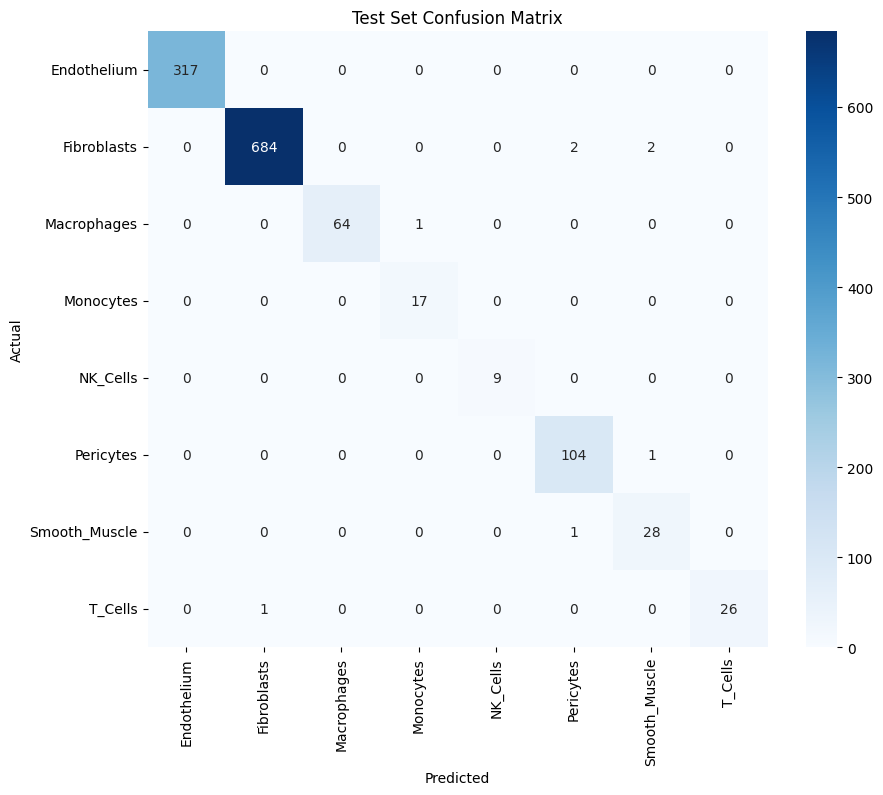

In [ ]:
test_pred = pd.DataFrame(ProtoCloud.model.get_predictions(model, torch.tensor(test_X, dtype=torch.float32, device=device)))
test_pred = ProtoCloud.utils.process_prediction_file(
    test_pred, train_data.cell_encoder,
    label=train_data.cell_encoder.inverse_transform(test_Y))

def plot_cm(y_true, y_pred, encoder, title="Confusion Matrix"):
    y_true_names = encoder.inverse_transform(y_true)
    y_pred_names = encoder.inverse_transform(y_pred)

    cm = confusion_matrix(y_true_names, y_pred_names, labels=encoder.classes_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_,
                cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_cm(test_Y, test_pred['idx1'], train_data.cell_encoder, "Test Set Confusion Matrix")

In [ ]:
# Load model architecture and weights
MODEL_DIR_HEALTHY_TRAIN = MODEL_DIR + HEALTHY_DATA_TRAIN_FILE_NAME + "/"
EXP_CODE = 'trained_model'
model = ProtoCloud.model.load_model(MODEL_DIR_HEALTHY_TRAIN, exp_code=EXP_CODE, device=device)
cell_encoder = ProtoCloud.utils.data_info_loader('cell_encoder', MODEL_DIR_HEALTHY_TRAIN)
model.eval()
print('Model loaded successfully')

Model loaded
Model loaded successfully
